## Prefix Sum

### Implementation

In [138]:
arr = [1, 4, 5, 4, -1]
prefix = [0] * len(arr)

prefix[0] = arr[0]
for i in range(1, len(arr)):
    prefix[i] = prefix[i-1] + arr[i]

print(prefix)

[1, 5, 10, 14, 13]


### Time and Space Complexity Analysis


1. Time Complexity = O(n)
2. Space Complexity = O(n)

In [139]:
def get_prefix_sum(arr):
    prefix = [0] * len(arr)

    prefix[0] = arr[0]
    for i in range(1, len(arr)):
        prefix[i] = prefix[i-1] + arr[i]

    return prefix

prefix = get_prefix_sum([2,3,1,2,4,3]) # O(N)
prefix

[2, 5, 6, 8, 12, 15]

In [140]:
def get_prefix_range_sum(prefix, target: int):
    g = [0] * len(prefix)
    g[0] = prefix[0] - target
    for i in range(1, len(prefix)):
        g[i] = prefix[i - 1] - target
    return g
get_prefix_range_sum(prefix, 7)

[-5, -5, -2, -1, 1, 5]

---

## 1. Range Sum Query - Immutable (LeetCode 303)

In [141]:
class NumArray:
    def __init__(self, nums): # Time Complexity: o(N), Space Complexity: O(N)
        self.nums = nums
        self.N = len(self.nums)
        self.prefix_sum = [0] * self.N
        self.build_prefix_sum()


    def sumRange(self, left: int, right: int) -> int:
        if left == 0:
            return self.prefix_sum[right]
        return self.prefix_sum[right] - self.prefix_sum[left - 1]


    def build_prefix_sum(self) -> None:
        self.prefix_sum[0] = self.nums[0]
        for i in range(1, self.N):
            self.prefix_sum[i] = self.prefix_sum[i - 1] + self.nums[i]
        
obj = NumArray([-2, 0, 3, -5, 2, -1])
print(obj.sumRange(0, 2))
print(obj.sumRange(2, 5))
print(obj.sumRange(0, 5))

1
-1
-3


---

### 22-07-2026 | 22nd July 2026

## 2. Find Pivot Index (LeetCode 724)

In [142]:
class Solution:
    def pivotIndex(self, nums) -> int: # Time Complexity: o(N), Space Complexity: O(N)
        prefix = self._get_prefix_sum(nums)
        total_sum = prefix[-1]

        for i in range(len(prefix)):
            left_sum = 0 if i == 0 else prefix[i-1]
            right_sum = total_sum - left_sum - nums[i]

            if left_sum == right_sum:
                return i
        
        return -1

    def _get_prefix_sum(self, nums):
        prefix = [0] * len(nums)
        prefix[0] = nums[0]

        for i in range(1, len(prefix)):
            prefix[i] = prefix[i-1] + nums[i]
        
        return prefix
s = Solution()
s.pivotIndex([1,7,3,6,5,6])

3

## 3. Left and Right Sum Differences (LeetCode 2574)

In [143]:
class Solution:
    def leftRightDifference(self, nums): # Time Complexity: o(N), Space Complexity: O(N)
        self.prefix_sum = self._get_prefix_sum(nums)
        total_sum = self.prefix_sum[-1]
        left_sum = [0] * len(nums)
        right_sum = [0] * len(nums)
        final_arr = [0] * len(nums)

        for i in range(len(nums)):
            left = 0 if i == 0 else self.prefix_sum[i-1]
            right = total_sum - left - nums[i]
            
            left_sum[i] = left
            right_sum[i] = right

            final_arr[i] = abs(left_sum[i] - right_sum[i])

        return final_arr

    def _get_prefix_sum(self, nums):
        prefix_sum = [0] * len(nums)
        prefix_sum[0] = nums[0]
        for i in range(1, len(prefix_sum)):
            prefix_sum[i] = prefix_sum[i - 1] + nums[i]
        
        return prefix_sum
s = Solution()
s.leftRightDifference([10,4,8,3])

[15, 1, 11, 22]

---

## 4. Find the N-th Value After K Seconds (LeetCode 3179)

In [144]:
class Solution:
    def valueAfterKSeconds(self, n: int, k: int) -> int:
        # Time Complexity: O(n * k)
        # Space Complexity; O(n)
        nums = [1] * n
        t = 0
        pivot = [0] * n
        pivot[0] = nums[0]

        while t != k:
            for i in range(1, len(nums)):
                pivot[i] = pivot[i-1] + nums[i] 
            nums = pivot[:]
            t += 1

        return pivot[-1] % (10 ** 9 + 7)
s = Solution()
s.valueAfterKSeconds(n = 4, k = 5)

56

---

### 23rd July 2026

## Concept of Prefix sum on 2d Matrix

#### Computing Prefix Sum for 2d Matrix

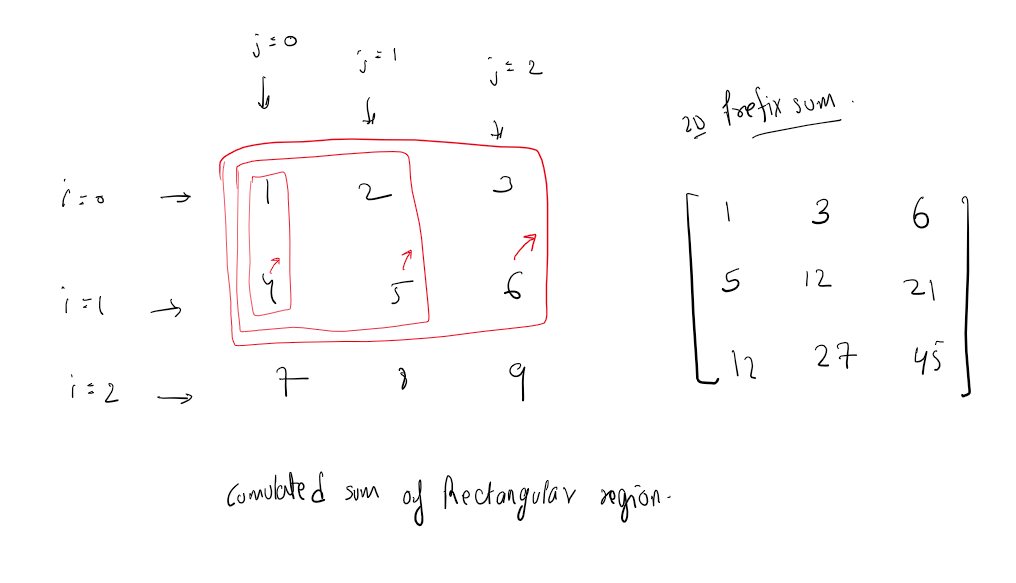

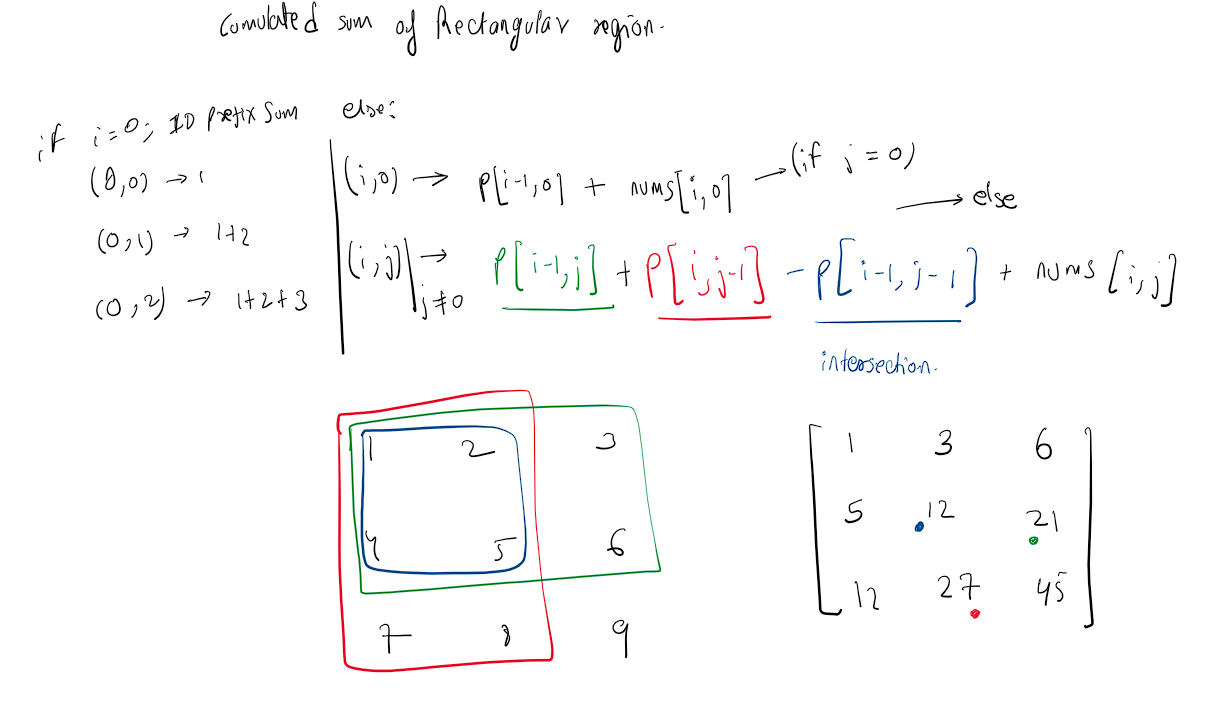

In [151]:
def compute_2d_prefix_sum(matrix):
    m = len(matrix)
    n = len(matrix[0])

    prefix_matrix = [[0] * n for _ in range(m)]
    prefix_matrix[0][0] = matrix[0][0]

    for i in range(m):
        for j in range(n):
            top = prefix_matrix[i-1][j] if i > 0 else 0
            left = prefix_matrix[i][j-1] if j > 0 else 0
            diag = prefix_matrix[i-1][j-1] if (i > 0 and j >0) else 0
            # prefix_matrix[i][j] =  + prefix_matrix[i][j-1] - prefix_matrix[i-1][j-1] + matrix[i][j]
            prefix_matrix[i][j] =  top + left - diag + matrix[i][j]
    return prefix_matrix

### Range Sum in 2d Matrix

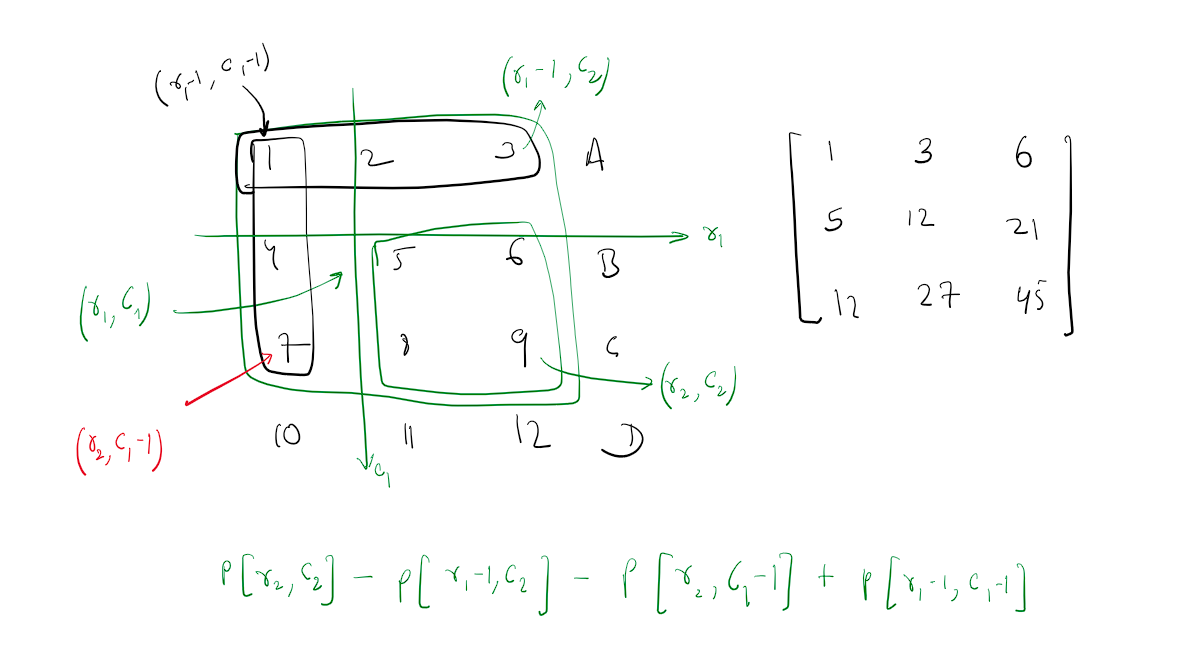

In [152]:
def get_rectange_range_sum(prefix, start_cord: tuple, end_cord: tuple):
    # NOTE: I'm not checking for invalid r's and c's
    r1, c1 = start_cord
    r2, c2 = end_cord
    p = prefix
    
    total = p[r2][c2]
    bottom = p[r1-1][c2] if r1 > 0 else 0
    top = p[r2][c1-1] if c1 > 0 else 0
    diag = p[r1 - 1][c1 - 1] if (r1 > 0 and c1 > 0) else 0
    range_sum = total - top - bottom + diag
    return range_sum

In [154]:
# matrix = [[4, 3, -1], [2, 1, 6], [9, 3, 2], [-1, 3, -1]]
matrix = [[1, 2, 3], [4, 5, 6], [7, 8, 9]]
m2 = [[3, 1, 4, 2], [5, 6, 7, 8], [9, 10, 11, 12], [1, 2, 3, 4]]
prefix = compute_2d_prefix_sum(matrix)
r1, c1 = 0, 0
r2, c2 = 3, 3
# range_sum = get_rectange_range_sum(prefix = prefix, start_cord = (0, 0), end_cord = (3, 3))
print(f"Matrix: {matrix}")
print(f"Prefix: {prefix}")
# print(f"Sum = {range_sum} | (r1, c1) = {r1, c1} | (r2, c2) = {r2, c2}")

Matrix: [[1, 2, 3], [4, 5, 6], [7, 8, 9]]
Prefix: [[1, 3, 6], [5, 12, 21], [12, 27, 45]]


## 304. Range Sum Query 2D - Immutable

In [156]:
class NumMatrix:
    def __init__(self, matrix):
        self.prefix = self.__get_prefix(matrix)

    def sumRegion(self, row1: int, col1: int, row2: int, col2: int) -> int:
        p = self.prefix
        r1, c1, r2, c2 = row1, col1, row2, col2

        total = p[r2][c2]
        top = p[r1 - 1][c2] if r1 > 0 else 0
        bottom = p[r2][c1 - 1] if c1 > 0 else 0
        diag = p[r1-1][c1-1] if (r1 > 0 and c1 > 0) else 0
        return total - top - bottom + diag

    def __get_prefix(self, matrix):
        m = len(matrix)
        n = len(matrix[0])

        prefix = [[0] * n for _ in range(m)]

        for i in range(m):
            for j in range(n):
                top = prefix[i-1][j] if i > 0 else 0
                bottom = prefix[i][j-1] if j > 0 else 0
                diag = prefix[i-1][j-1] if (i > 0 and j > 0) else 0
                current = matrix[i][j]

                prefix[i][j] = top + bottom - diag + current
        return prefix

n = NumMatrix(matrix)
n.sumRegion(1, 1, 2, 2)

28